In [1]:
import pandas as pd
df=pd.read_csv("data/DB_final.csv")

In [ ]:
from sklearn.model_selection import train_test_split

if df.isnull().sum().sum() > 0:
    raise ValueError(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

X = df.drop(columns=['Text','Writer', 'is_AI'])
z = df['is_AI'] 


X_train, X_test, z_train, z_test= train_test_split(
    X, 
    z, 
    test_size=0.20, 
    random_state=999, 
    stratify=z           # same class distribution in train and test
)


print(f"X Train/Test: {X_train.shape} , {X_test.shape}")
print(f"z Train/Test: {len(z_train)} , {len(z_test)}")

X Train/Test: (40944, 16) , (10237, 16)
z Train/Test: 40944 , 10237


In [ ]:
import xgboost as xgb
import torch

xgb_is_ai = xgb.XGBClassifier(
    objective='binary:logistic', 
    tree_method='hist',
    eval_metric=['logloss', 'auc'],
    device='cuda' if torch.cuda.is_available() else 'cpu',
    n_estimators=2000,
    early_stopping_rounds=50,
    learning_rate=0.05,
    max_depth=10,
    random_state=999
)

print("Starting training on GPU...")
xgb_is_ai.fit(X_train, z_train, eval_set=[(X_test, z_test)], verbose=100)
print("Training completed!")

Starting training on GPU...
[0]	validation_0-logloss:0.37148	validation_0-auc:0.97776
[100]	validation_0-logloss:0.05357	validation_0-auc:0.99540
[200]	validation_0-logloss:0.04995	validation_0-auc:0.99619
[300]	validation_0-logloss:0.05052	validation_0-auc:0.99629
[306]	validation_0-logloss:0.05068	validation_0-auc:0.99630
Training completed!


              precision    recall  f1-score   support

       Human       0.96      0.93      0.94      1459
          AI       0.99      0.99      0.99      8778

    accuracy                           0.98     10237
   macro avg       0.97      0.96      0.97     10237
weighted avg       0.98      0.98      0.98     10237



/home/basel/Work/python/ai_text_detection/.venv/lib/python3.11/site-packages/xgboost/core.py:774: UserWarning: [04:42:06] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


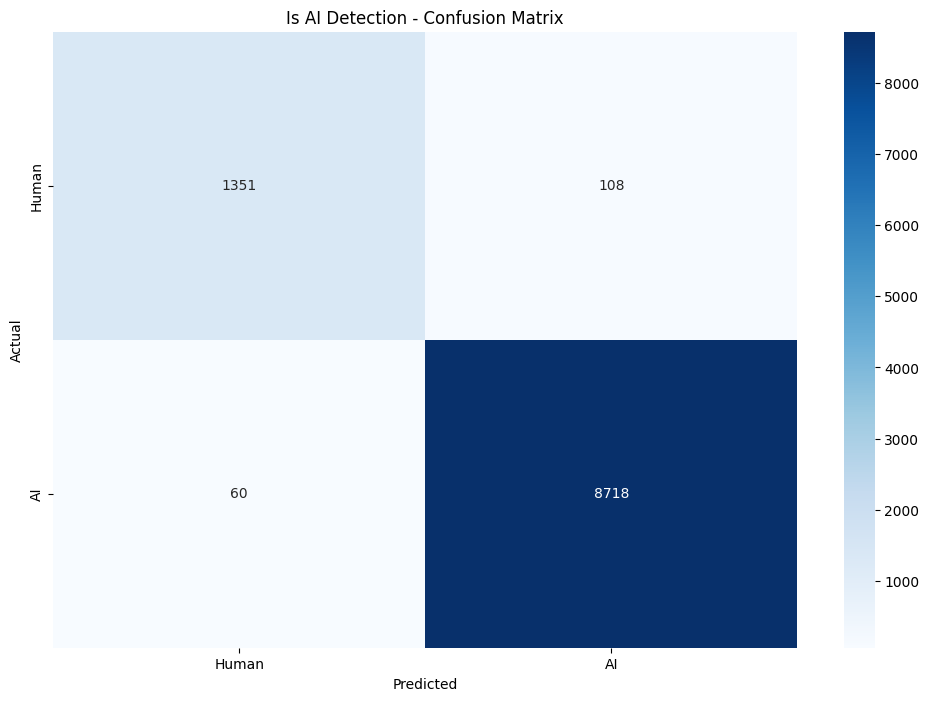

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

z_pred = xgb_is_ai.predict(X_test)

print(classification_report(z_test, z_pred, target_names=['Human', 'AI']))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(z_test, z_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()


/tmp/ipykernel_125591/919564633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


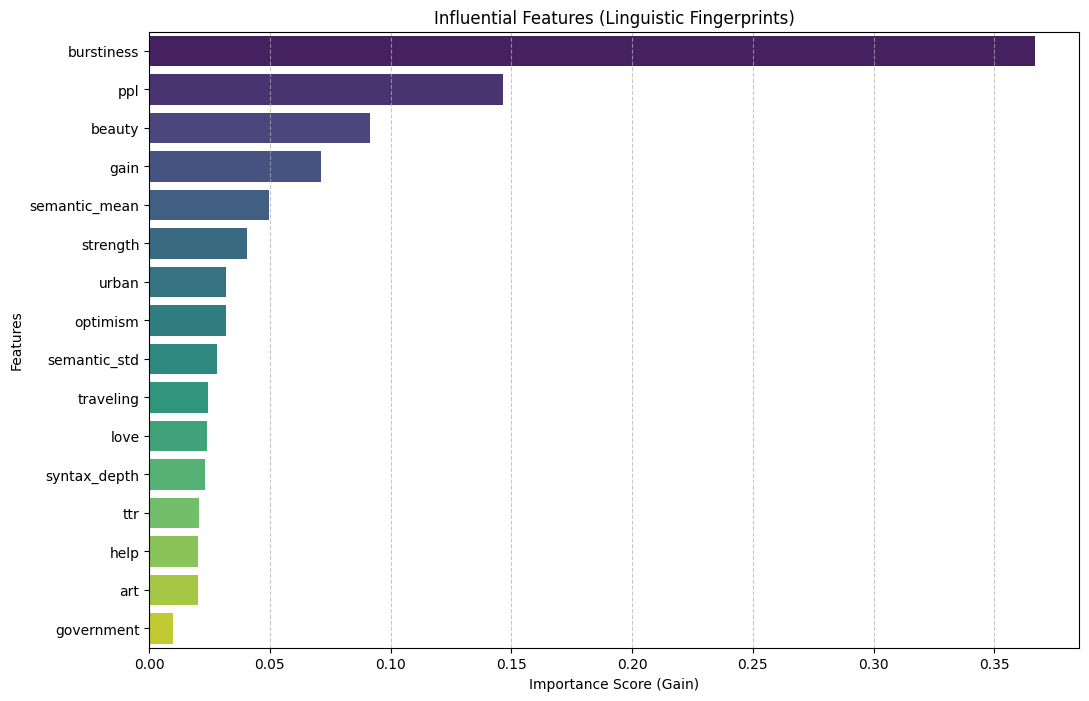

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = xgb_is_ai.feature_importances_
feature_names = X.columns 


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Influential Features (Linguistic Fingerprints)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



In [ ]:
# save model
import joblib

joblib.dump(xgb_is_ai, 'models/xgb_is_ai_model.pkl')

['models/xgb_is_ai_model.pkl']